# K-Nearest Neighbors (K-NN)

## Importing the libraries

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [36]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

# Assign column names to the dataset
names = names = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates']
# Read dataset to pandas dataframe
dataset = pd.read_csv(url, sep=';')

## Data Analysis EDA

In [37]:
dataset.shape

(1599, 12)

In [38]:
dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [39]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [40]:
dataset.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [46]:
dataset.groupby('fixed acidity').size()

,0
fixed acidity,
4.6,1
4.7,1
4.9,1
5.0,6
5.1,4
...,...
14.3,1
15.0,2
15.5,2


In [47]:
print(dataset.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


## Data Preprocessing

In [48]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

## Splitting the dataset into the Training set and Test set

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.20,
                                                    random_state = 0)

## Feature Scaling

In [50]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
print(X_train)

[[ 0.61303014  0.10850105  0.94751783  0.73603967]
 [-0.56776627 -0.12400121  0.38491447  0.34808318]
 [-0.80392556  1.03851009 -1.30289562 -1.3330616 ]
 [ 0.25879121 -0.12400121  0.60995581  0.73603967]
 [ 0.61303014 -0.58900572  1.00377816  1.25331499]
 [-0.80392556 -0.82150798  0.04735245  0.21876435]
 [-0.21352735  1.73601687 -1.19037495 -1.20374277]
 [ 0.14071157 -0.82150798  0.72247648  0.47740201]
 [ 0.02263193 -0.12400121  0.21613346  0.34808318]
 [-0.09544771 -1.05401024  0.10361279 -0.03987331]
 [ 1.0853487  -0.12400121  0.94751783  1.12399616]
 [-1.39432376  0.34100331 -1.41541629 -1.3330616 ]
 [ 1.20342834  0.10850105  0.72247648  1.38263382]
 [-1.04008484  1.03851009 -1.24663528 -0.81578628]
 [-0.56776627  1.50351461 -1.30289562 -1.3330616 ]
 [-1.04008484 -2.4490238  -0.1776889  -0.29851096]
 [ 0.73110978 -0.12400121  0.94751783  0.73603967]
 [ 0.96726906  0.57350557  1.0600385   1.64127148]
 [ 0.14071157 -1.98401928  0.66621615  0.34808318]
 [ 0.96726906 -1.2865125   1.11

In [51]:
print(X_test)

[[ 1.41998736 -0.32881689  0.80712824 ... -0.90851928  0.57743564
   0.36384892]
 [-0.13687277  1.58928164 -1.39201131 ...  0.32598793 -0.73852533
  -0.76727388]
 [ 0.43974209 -1.31526756  0.29570044 ... -0.3237527   1.03516119
   1.21219102]
 ...
 [ 0.43974209 -1.04125349  0.75598546 ... -0.84354521 -0.62409394
   0.92941032]
 [ 0.43974209  1.28786615 -1.18744019 ... -0.12883051 -0.68130963
  -0.67301364]
 [-0.07921128 -1.15085912  0.75598546 ... -0.25877864 -0.62409394
   1.77775242]]


## Training the K-NN model on the Training set

In [54]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=11,p=2,metric='cityblock')
classifier.fit(X_train,y_train)

KNeighborsClassifier(metric='cityblock', n_neighbors=11)

## Getting nearest neighbours for each point in training data

In [55]:
classifier.kneighbors(X=X_train, n_neighbors=7, return_distance=False)

array([[ 794,    0,  947, ...,  424,  307,  108],
       [   1,  853,  124, ...,  341,  904,  692],
       [   2,   31,  421, ..., 1048, 1152,  482],
       ...,
       [1276,  608,  306, ..., 1103,  934,  880],
       [1277,  210,   66, ...,  574,  404,  963],
       [1278, 1124,  711, ...,  192,  705,  783]])

In [56]:
dataset.iloc[[  0,  16,  73,  55,  54,  60,  29],-1]

,quality
0,5
16,7
73,4
55,5
54,6
60,5
29,6


In [57]:
classifier.predict(X_train[[1]])

array([5])

## Predicting the Test set results

In [58]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1),y_test.reshape(len(y_test),1)),1))

[[5 6]
 [5 5]
 [7 7]
 [5 6]
 [6 5]
 [5 6]
 [5 5]
 [6 6]
 [5 4]
 [6 5]
 [6 5]
 [5 5]
 [6 6]
 [6 5]
 [5 6]
 [7 6]
 [7 7]
 [5 5]
 [5 5]
 [5 4]
 [6 7]
 [5 6]
 [6 6]
 [6 4]
 [6 6]
 [5 5]
 [6 5]
 [7 7]
 [5 5]
 [6 6]
 [7 5]
 [6 6]
 [6 5]
 [5 6]
 [6 7]
 [6 7]
 [5 5]
 [6 6]
 [6 6]
 [6 7]
 [5 5]
 [6 7]
 [7 6]
 [7 6]
 [6 5]
 [6 5]
 [5 6]
 [6 6]
 [5 6]
 [6 5]
 [5 5]
 [5 5]
 [5 6]
 [6 6]
 [5 6]
 [5 5]
 [5 5]
 [5 5]
 [7 6]
 [6 5]
 [6 5]
 [6 6]
 [6 6]
 [6 6]
 [5 5]
 [6 6]
 [5 5]
 [6 5]
 [7 6]
 [5 6]
 [5 6]
 [5 6]
 [5 4]
 [6 6]
 [6 5]
 [6 6]
 [6 5]
 [6 5]
 [5 5]
 [7 6]
 [6 6]
 [5 5]
 [6 6]
 [6 6]
 [6 6]
 [5 5]
 [6 6]
 [5 5]
 [5 5]
 [5 5]
 [5 5]
 [5 6]
 [6 4]
 [6 5]
 [7 7]
 [5 6]
 [6 6]
 [6 5]
 [5 6]
 [6 5]
 [7 8]
 [6 6]
 [6 6]
 [6 6]
 [5 5]
 [5 5]
 [5 5]
 [5 5]
 [6 7]
 [5 5]
 [6 6]
 [5 5]
 [7 7]
 [5 5]
 [6 6]
 [6 6]
 [5 6]
 [7 7]
 [6 6]
 [6 6]
 [5 5]
 [6 7]
 [5 5]
 [5 5]
 [6 6]
 [7 6]
 [5 5]
 [5 5]
 [5 5]
 [7 6]
 [5 6]
 [5 6]
 [6 6]
 [6 6]
 [6 6]
 [5 5]
 [6 6]
 [5 5]
 [6 8]
 [5 5]
 [6 6]
 [5 5]
 [5 6]

## Evaluating the Algorithm
## Making the Confusion Matrix & Predicting Accuracy Score

In [59]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test,y_pred)
print(cm)
accuracy = accuracy_score(y_test, y_pred)*100
print('Accuracy of our model is equal ' + str(round(accuracy, 2)) + ' %.')

[[ 0  0  2  0  0  0]
 [ 0  0  8  3  0  0]
 [ 0  1 95 35  4  0]
 [ 0  0 44 83 15  0]
 [ 0  0  2 12 13  0]
 [ 0  0  0  1  2  0]]
Accuracy of our model is equal 59.69 %.


## Making Classification Report

In [62]:
from sklearn.metrics import classification_report
# here f1 score is goodness of fit .
print(classification_report(y_test, y_pred, zero_division=1))


              precision    recall  f1-score   support

           3       1.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.63      0.70      0.66       135
           6       0.62      0.58      0.60       142
           7       0.38      0.48      0.43        27
           8       1.00      0.00      0.00         3

    accuracy                           0.60       320
   macro avg       0.61      0.29      0.28       320
weighted avg       0.59      0.60      0.58       320



## Comparing Error Rate with the K Value
## Parameter Tuning Using
##cross-validation for parameter tuning:

In [69]:
from sklearn.model_selection import cross_val_score

# creating list of K for KNN
k_list = list(range(1,50))

# creating list of cv scores
cv_scores = []

# perform 10-fold cross validation
for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=8, scoring='accuracy')
    cv_scores.append(scores.mean())


## plot the error values against K values

<Figure size 640x480 with 0 Axes>

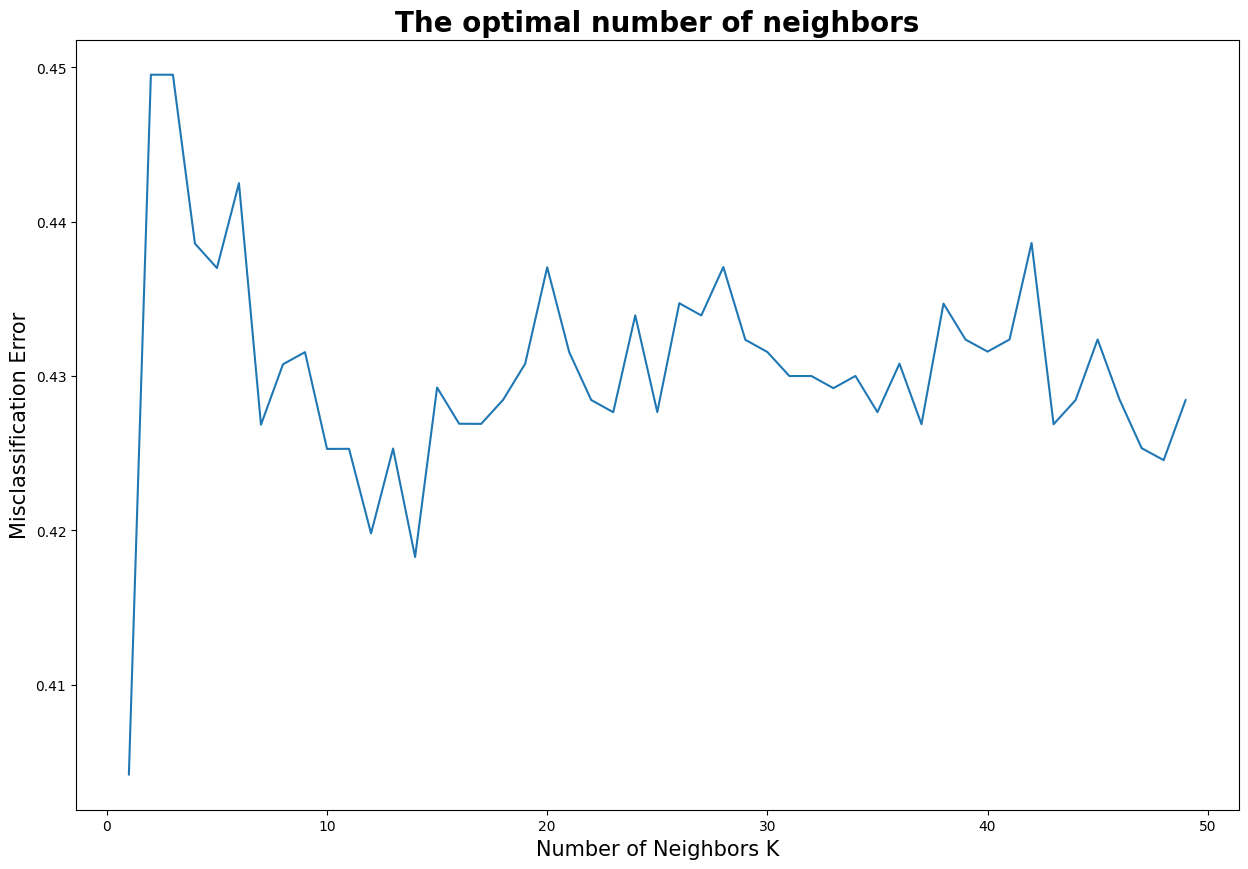

In [70]:
import seaborn as sns

# changing to misclassification error
MSE = [1-x for x in cv_scores]

plt.figure()
plt.figure(figsize=(15,10))
plt.title('The optimal number of neighbors', fontsize=20, fontweight='bold')
plt.xlabel('Number of Neighbors K', fontsize=15)
plt.ylabel('Misclassification Error', fontsize=15)
sns.set_style("whitegrid")
plt.plot(k_list, MSE)

plt.show()

## finding best k

In [71]:
best_k = k_list[MSE.index(min(MSE))]
print("The optimal number of neighbors is %d." % best_k)

The optimal number of neighbors is 1.


## Visualize Test Result of KNN

<ipython-input-75-65ad04b64aff>:9: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],c=cmap(idx), marker=markers[idx], label=cl)


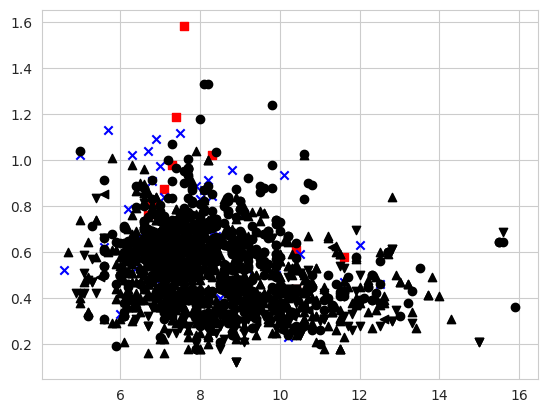

In [75]:
from matplotlib.colors import ListedColormap

# Add more markers if there are more unique classes in 'y'
markers = ('s', 'x', 'o', '^', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'x', 'D', 'd', '|')
colors = ('red', 'blue', 'black')
cmap = ListedColormap(colors[:len(np.unique(y_test))])

for idx, cl in enumerate(np.unique(y)):
    plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],c=cmap(idx), marker=markers[idx], label=cl)